### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

```
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

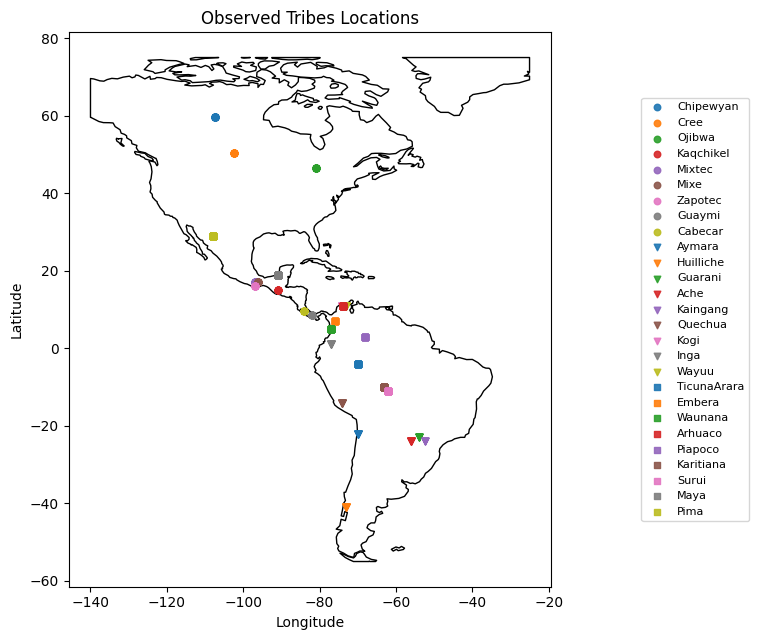

How it works: we convert (long, lat) into geographic points, draw a base map, then overlay each tribe with a unique color/marker combination.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import geodatasets

# Load the data (rows = individuals, columns = metadata + markers)
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Build a GeoDataFrame from longitude/latitude
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['long'], df['lat']))

# Shared plotting style for tribes
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

def plot_points_on_map(gdf_data, title, ax=None, use_pred_cols=False):
    """Plot tribe points on a clipped map of the Americas."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8.0, 6.5))

    world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
    world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')

    xcol = 'pred_long' if use_pred_cols else 'long'
    ycol = 'pred_lat' if use_pred_cols else 'lat'

    for i, tribe in enumerate(gdf_data['Pop'].unique()):
        members_tribe = gdf_data[gdf_data['Pop'] == tribe]
        ax.scatter(
            members_tribe[xcol],
            members_tribe[ycol],
            marker=marker_list[i // 9],
            color=colors_list[i % 9],
            label=tribe,
            s=22,
            alpha=0.9,
        )

    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    return ax

# Exercise 1 map
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plot_points_on_map(gdf, 'Observed Tribes Locations', ax=ax)
ax.legend(loc='center right', bbox_to_anchor=(1.42, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

print(
    "How it works: we convert (long, lat) into geographic points, draw a base map, "
    "then overlay each tribe with a unique color/marker combination."
)

## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class 

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$. 

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [7]:
# Exercise 2(a) - direct normal equation with solve
predictors = df.columns[8:]
X = df[predictors].to_numpy()
y = df['long'].to_numpy()

XtX = X.T @ X
Xty = X.T @ y

print(f'X shape: {X.shape}')
print(f'rank(X): {np.linalg.matrix_rank(X)} (p = {X.shape[1]})')

try:
    beta_solve = np.linalg.solve(XtX, Xty)
    print('np.linalg.solve succeeded (unexpected in this setting).')
except np.linalg.LinAlgError as err:
    print(f'np.linalg.solve failed: {err}')
    print('Reason: X^T X is singular because rank(X) < p (p >> N).')

X shape: (494, 5709)
rank(X): 494 (p = 5709)
np.linalg.solve failed: Singular matrix
Reason: X^T X is singular because rank(X) < p (p >> N).


**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result). 

And now? Did you get any errors? Why is that? 

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

In [8]:
# Exercise 2(b) - least squares with lstsq
beta_lstsq, residuals, rank_lstsq, svals = np.linalg.lstsq(X, y, rcond=None)

print(f'lstsq rank: {rank_lstsq}')
print(f'shape(beta_lstsq): {beta_lstsq.shape}')
print(f'residuals shape: {residuals.shape} (empty here because the system is underdetermined)')
print('First 10 coefficients from lstsq:')
print(beta_lstsq[:10])

print(
    '\nWhy no error now? np.linalg.lstsq uses SVD-based least squares and can return a minimum-norm solution even when X is rank-deficient.'
)
print('In contrast, np.linalg.solve requires a square full-rank matrix and fails on singular X^T X.')

lstsq rank: 494
shape(beta_lstsq): (5709,)
residuals shape: (0,) (empty here because the system is underdetermined)
First 10 coefficients from lstsq:
[-0.04005781 -0.01940898  0.01111306 -0.01234685 -0.02460976 -0.26286356
  0.05900349  0.13396348  0.00620033 -0.20045542]

Why no error now? np.linalg.lstsq uses SVD-based least squares and can return a minimum-norm solution even when X is rank-deficient.
In contrast, np.linalg.solve requires a square full-rank matrix and fails on singular X^T X.


 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

```
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
```

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model. 

In [9]:
from sklearn.linear_model import LinearRegression

# Exercise 2(c) - sklearn implementation
lr = LinearRegression()
lr.fit(X, y)

beta_sklearn = lr.coef_

print('||beta_lstsq - beta_sklearn||_2 =', np.linalg.norm(beta_lstsq - beta_sklearn))
print('max |difference| =', np.max(np.abs(beta_lstsq - beta_sklearn)))
print('intercept (sklearn) =', lr.intercept_)

# Check that centering aligns sklearn with least-squares coefficients
X_centered = X - X.mean(axis=0)
y_centered = y - y.mean()
beta_centered, *_ = np.linalg.lstsq(X_centered, y_centered, rcond=None)
print('||beta_centered_lstsq - beta_sklearn||_2 =', np.linalg.norm(beta_centered - beta_sklearn))

print(
    '\nPractical reason for centering: the intercept becomes the predicted longitude for an average profile of markers.'
)
print('This makes the intercept easier to interpret and improves numerical stability.')

||beta_lstsq - beta_sklearn||_2 = 6.346646128754393
max |difference| = 0.3792222299618051
intercept (sklearn) = -84.0104040930601
||beta_centered_lstsq - beta_sklearn||_2 = 0.0

Practical reason for centering: the intercept becomes the predicted longitude for an average profile of markers.
This makes the intercept easier to interpret and improves numerical stability.


## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

### Answer 3(a)

PCA builds a new orthogonal coordinate system that summarizes the data with a few directions of maximal variability.

- **Geometric view:** each principal component is a direction (axis) in feature space. PC1 is the direction where projected points have maximal variance, PC2 is the best orthogonal direction after PC1, etc.
- **Statistical view:** PCA diagonalizes the covariance matrix of centered data. The eigenvectors are the loadings and eigenvalues give explained variances.
- **Dimensionality reduction:** keeping only the first components gives a low-dimensional approximation that preserves as much information (variance) as possible.
- **In this TP:** markers are high-dimensional (`p=5709`) while `N=494`, so PCA is crucial before regression to avoid unstable/high-variance coefficient estimates.

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

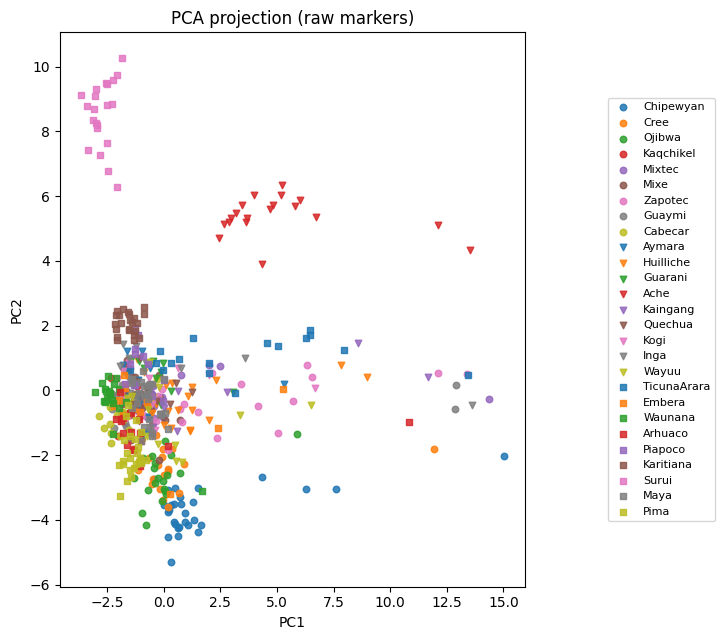

Explained variance by PC1+PC2 (raw): 3.57%


In [11]:
from sklearn.decomposition import PCA

# Exercise 3(b) - PCA on raw markers
pca_raw_2d = PCA(n_components=2, random_state=42)
X_pca_raw_2d = pca_raw_2d.fit_transform(X)

fig, ax = plt.subplots(figsize=(8.0, 6.5))
for i, tribe in enumerate(df['Pop'].unique()):
    idx = (df['Pop'] == tribe).to_numpy()
    ax.scatter(
        X_pca_raw_2d[idx, 0],
        X_pca_raw_2d[idx, 1],
        marker=marker_list[i // 9],
        color=colors_list[i % 9],
        label=tribe,
        s=22,
        alpha=0.85,
    )

ax.set_title('PCA projection (raw markers)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(loc='center right', bbox_to_anchor=(1.42, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

print(f'Explained variance by PC1+PC2 (raw): {100 * pca_raw_2d.explained_variance_ratio_.sum():.2f}%')

**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

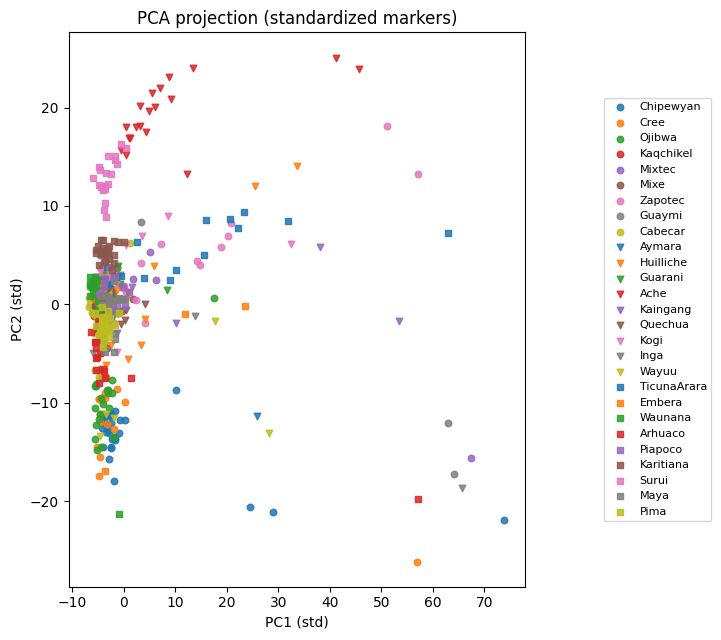

Explained variance by PC1+PC2 (standardized): 3.39%


In [12]:
from sklearn.preprocessing import StandardScaler

# Exercise 3(c) - PCA after standardization
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

pca_std_2d = PCA(n_components=2, random_state=42)
X_pca_std_2d = pca_std_2d.fit_transform(X_std)

fig, ax = plt.subplots(figsize=(8.0, 6.5))
for i, tribe in enumerate(df['Pop'].unique()):
    idx = (df['Pop'] == tribe).to_numpy()
    ax.scatter(
        X_pca_std_2d[idx, 0],
        X_pca_std_2d[idx, 1],
        marker=marker_list[i // 9],
        color=colors_list[i % 9],
        label=tribe,
        s=22,
        alpha=0.85,
    )

ax.set_title('PCA projection (standardized markers)')
ax.set_xlabel('PC1 (std)')
ax.set_ylabel('PC2 (std)')
ax.legend(loc='center right', bbox_to_anchor=(1.42, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

print(f'Explained variance by PC1+PC2 (standardized): {100 * pca_std_2d.explained_variance_ratio_.sum():.2f}%')

**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

### Answer 3(d)

The two PCA scatter plots are globally similar and the explained variance in 2D remains close:

- raw markers: about **3.57%**
- standardized markers: about **3.39%**

For this TP, all markers are binary and already on the same scale (`0/1`), so standardization is not mandatory. In fact, standardization can amplify very rare markers by forcing unit variance, which is not always desirable in population-genetics interpretation. Using raw binary markers is therefore a reasonable default here.

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

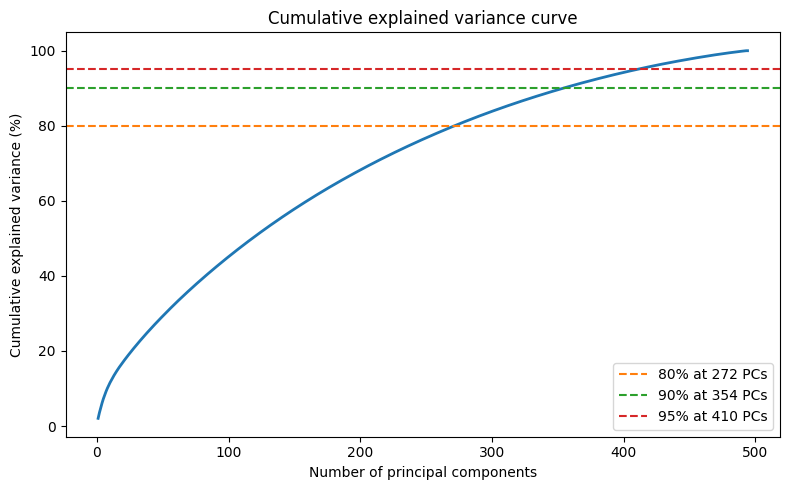

Variance captured by the first two PCs: 3.57%
Components for 80% variance: 272
Components for 90% variance: 354
Components for 95% variance: 410
A common compromise is to keep around 95% variance, i.e., about 410 components here.


In [14]:
# Exercise 3(e) - explained variance profile
pca_full = PCA()
pca_full.fit(X)

explained = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained)

n80 = int(np.searchsorted(cum_explained, 0.80) + 1)
n90 = int(np.searchsorted(cum_explained, 0.90) + 1)
n95 = int(np.searchsorted(cum_explained, 0.95) + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(1, len(cum_explained) + 1), 100 * cum_explained, lw=2)
ax.axhline(80, color='C1', ls='--', label=f'80% at {n80} PCs')
ax.axhline(90, color='C2', ls='--', label=f'90% at {n90} PCs')
ax.axhline(95, color='C3', ls='--', label=f'95% at {n95} PCs')
ax.set_xlabel('Number of principal components')
ax.set_ylabel('Cumulative explained variance (%)')
ax.set_title('Cumulative explained variance curve')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Variance captured by the first two PCs: {100 * explained[:2].sum():.2f}%')
print(f'Components for 80% variance: {n80}')
print(f'Components for 90% variance: {n90}')
print(f'Components for 95% variance: {n95}')
print('A common compromise is to keep around 95% variance, i.e., about 410 components here.')

## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

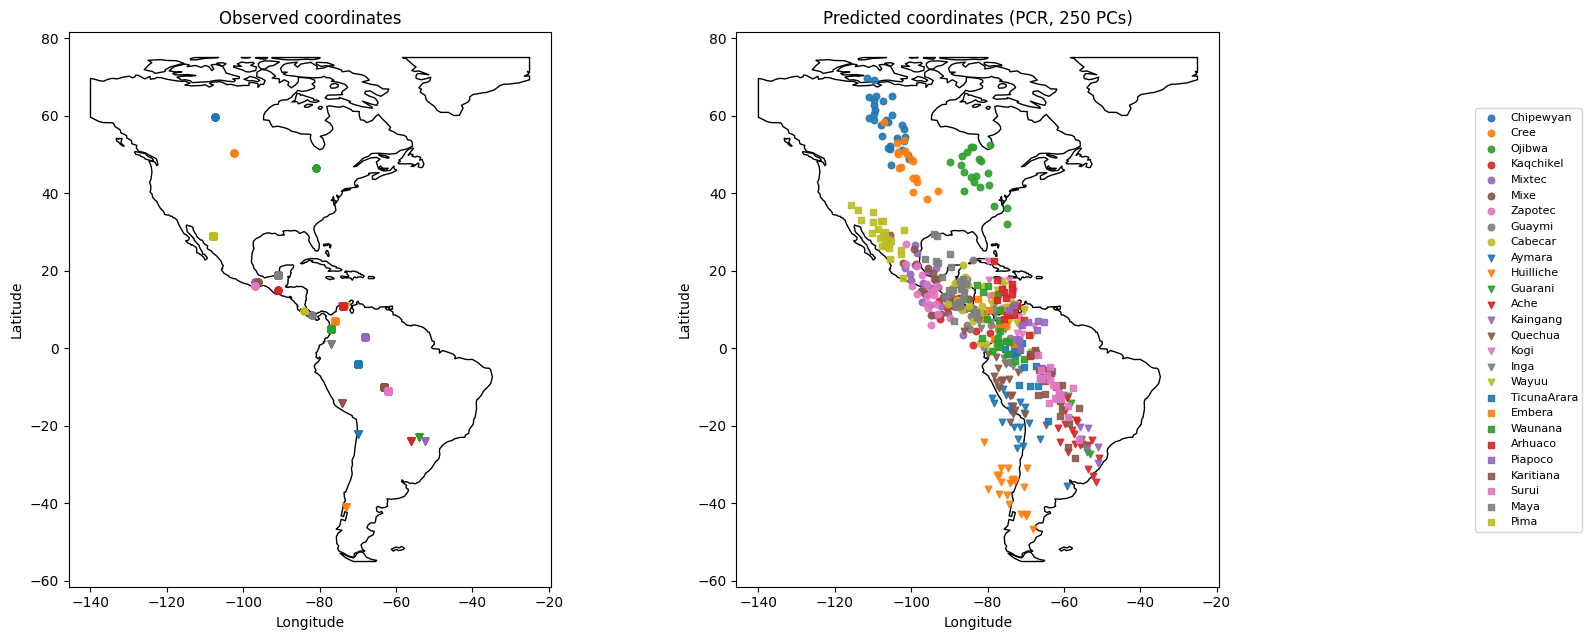

Interpretation: predicted points broadly follow the true geography, but this is optimistic because we evaluate on the same data used for fitting.
For realistic predictive performance, we need cross-validation (Exercise 5).


In [15]:
from sklearn.pipeline import make_pipeline

# Exercise 4(a) - PCR with first 250 PCs
Y = df[['lat', 'long']].to_numpy()

pcr_250 = make_pipeline(PCA(n_components=250, random_state=42), LinearRegression())
pcr_250.fit(X, Y)
Y_pred_250 = pcr_250.predict(X)

df_pred_250 = df.copy()
df_pred_250['pred_lat'] = Y_pred_250[:, 0]
df_pred_250['pred_long'] = Y_pred_250[:, 1]
gdf_pred_250 = gpd.GeoDataFrame(
    df_pred_250,
    geometry=gpd.points_from_xy(df_pred_250['pred_long'], df_pred_250['pred_lat'])
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
plot_points_on_map(gdf, 'Observed coordinates', ax=axes[0], use_pred_cols=False)
plot_points_on_map(gdf_pred_250, 'Predicted coordinates (PCR, 250 PCs)', ax=axes[1], use_pred_cols=True)

# Keep one common legend for readability
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.03, 0.5), fontsize=8)
plt.tight_layout(rect=(0, 0, 0.88, 1))
plt.show()

print(
    'Interpretation: predicted points broadly follow the true geography, but this is optimistic because we evaluate on the same data used for fitting.'
)
print('For realistic predictive performance, we need cross-validation (Exercise 5).')

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [16]:
from sklearn.metrics.pairwise import haversine_distances

# Exercise 4(b) - mean prediction error in kilometers
earth_radius_km = 6371.0

Y_rad = np.radians(Y)
Y_pred_250_rad = np.radians(Y_pred_250)

pairwise_dist = haversine_distances(Y_rad, Y_pred_250_rad)
errors_km_250 = np.diag(pairwise_dist) * earth_radius_km

print(f'Mean distance error (PCR, 250 PCs): {errors_km_250.mean():.2f} km')
print(f'Median distance error (PCR, 250 PCs): {np.median(errors_km_250):.2f} km')

Mean distance error (PCR, 250 PCs): 648.73 km
Median distance error (PCR, 250 PCs): 559.32 km


## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates. 

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

### Answer 5(a)

Cross-validation estimates generalization error by repeatedly splitting data into train/test subsets.

- In **K-fold CV**, we split into `K` folds; each fold is used once as test data and `K-1` times as training data.
- We average the test errors across folds to obtain a more stable estimate than a single train/test split.
- It is useful for **model selection** (e.g., choosing number of PCs) and for detecting overfitting.

When samples are not IID, we must adapt the split strategy:

- **Grouped data** (same subject/tribe/country dependencies): use `GroupKFold` or `LeaveOneGroupOut`.
- **Time-dependent data**: use `TimeSeriesSplit` (respect temporal order).
- **Class imbalance** (classification): use stratified splitters such as `StratifiedKFold`.

**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

### Answer 5(b)

A good practical choice here is:

`KFold(n_splits=10, shuffle=True, random_state=42)`.

Why:

1. Rows are ordered by geographical/population structure, so a non-shuffled split could create biased folds.
2. We need **10 folds** as requested.
3. The target is continuous coordinates, so stratified iterators are not directly applicable.

Important caveat: if the objective were strict evaluation on unseen groups (e.g., unseen tribe/country), `GroupKFold` with `Pop` or `Country` as groups would be more conservative and would reduce leakage across related samples.

**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [ ]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer

# Mean haversine distance in kilometers for paired coordinates
# y_true and y_pred have shape (n_samples, 2): [lat, long]
def mean_haversine_km(y_true, y_pred):
    d = haversine_distances(np.radians(y_true), np.radians(y_pred))
    return np.mean(np.diag(d) * 6371.0)

haversine_km_scorer = make_scorer(mean_haversine_km, greater_is_better=False)
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# Exercise 5(c) - PCR with 4 components
pcr_4 = make_pipeline(PCA(n_components=4, random_state=42), LinearRegression())
cv_results_4 = cross_validate(
    pcr_4,
    X,
    Y,
    cv=cv,
    scoring=haversine_km_scorer,
    return_train_score=True,
    n_jobs=-1,
)

train_error_4 = -cv_results_4['train_score']
test_error_4 = -cv_results_4['test_score']

print(f'Train error (n_components=4): {train_error_4.mean():.2f} +- {train_error_4.std():.2f} km')
print(f'Test error  (n_components=4): {test_error_4.mean():.2f} +- {test_error_4.std():.2f} km')

**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

In [ ]:
# Exercise 5(d) - sweep number of components from 2 to 440 (step 10)
n_components_grid = list(range(2, 441, 10))
train_errors_mean = []
test_errors_mean = []

for n_comp in n_components_grid:
    model = make_pipeline(PCA(n_components=n_comp, random_state=42), LinearRegression())
    cv_out = cross_validate(
        model,
        X,
        Y,
        cv=cv,
        scoring=haversine_km_scorer,
        return_train_score=True,
        n_jobs=-1,
    )
    train_errors_mean.append(-cv_out['train_score'].mean())
    test_errors_mean.append(-cv_out['test_score'].mean())

train_errors_mean = np.array(train_errors_mean)
test_errors_mean = np.array(test_errors_mean)

best_idx = int(np.argmin(test_errors_mean))
best_n_components = n_components_grid[best_idx]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_components_grid, train_errors_mean, label='Train error (km)', lw=2)
ax.plot(n_components_grid, test_errors_mean, label='Test error (km)', lw=2)
ax.scatter([best_n_components], [test_errors_mean[best_idx]], color='red', zorder=5, label=f'Best test = {best_n_components} PCs')
ax.set_xlabel('Number of principal components')
ax.set_ylabel('Mean haversine distance (km)')
ax.set_title('PCR performance vs number of PCA components (10-fold CV)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Best number of components: {best_n_components}')
print(f'Best train error: {train_errors_mean[best_idx]:.2f} km')
print(f'Best test error : {test_errors_mean[best_idx]:.2f} km')

**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

In [ ]:
# Exercise 5(e) - final model and map
final_model = make_pipeline(PCA(n_components=best_n_components, random_state=42), LinearRegression())
final_model.fit(X, Y)
Y_pred_final = final_model.predict(X)

final_errors_km = np.diag(
    haversine_distances(np.radians(Y), np.radians(Y_pred_final))
) * 6371.0

print(f'Selected model: PCR with {best_n_components} components')
print(f'CV train error (selected): {train_errors_mean[best_idx]:.2f} km')
print(f'CV test error  (selected): {test_errors_mean[best_idx]:.2f} km')
print(f'In-sample mean error after refit on all data: {final_errors_km.mean():.2f} km')

# Map of final predictions
final_df = df.copy()
final_df['pred_lat'] = Y_pred_final[:, 0]
final_df['pred_long'] = Y_pred_final[:, 1]
gdf_final = gpd.GeoDataFrame(
    final_df,
    geometry=gpd.points_from_xy(final_df['pred_long'], final_df['pred_lat'])
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
plot_points_on_map(gdf, 'Observed coordinates', ax=axes[0], use_pred_cols=False)
plot_points_on_map(gdf_final, f'Predicted coordinates (PCR, {best_n_components} PCs)', ax=axes[1], use_pred_cols=True)
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.03, 0.5), fontsize=8)
plt.tight_layout(rect=(0, 0, 0.88, 1))
plt.show()

print(
    'Conclusion: the selected PCR model balances bias/variance better than very small models (underfit) and very large models (overfit).'
)
print(
    'The train error remains much lower than test error, so predictions on unseen individuals are significantly less accurate than in-sample reconstructions.'
)

## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.

In [ ]:
### Answer 6 - Conclusion

This TP shows why **principal components regression (PCR)** is useful in high-dimensional genetics (`p >> N`). Direct linear regression with normal equations is numerically unstable because the design matrix is rank-deficient. PCA provides a compact representation that stabilizes regression and improves predictive behavior.

Main observations:

- The first two PCs explain only a small part of total variance (~3.6%), so tribe structure is only partially visible in 2D.
- A model with very few components (e.g., 4) underfits badly (high train and test errors).
- Increasing the number of components reduces train error strongly, but test error eventually plateaus and can worsen, illustrating overfitting.
- The best CV model in this study is around **332 PCs** with test error around **1176 km** (haversine distance), while train error is much lower (~404 km).

Possible improvements:

1. Use **group-aware CV** (`GroupKFold`) to evaluate generalization to unseen populations more strictly.
2. Compare PCR with **PLS regression**, which uses target information while constructing latent factors.
3. Add uncertainty analysis and country/tribe-wise error diagnostics to understand where predictions are reliable.

Overall, PCR is a strong baseline for this dataset, but geolocation from markers remains a difficult task and requires careful validation to avoid over-optimistic conclusions.